Figure S10: Allele frequency spectrum of pcQTL. Minor allele frequencies of lead variants for QTL credible sets discovered as pcQTLs or eQTLs as eQTLs are not significantly different (p=0.164). Minor allele frequencies for  novel pcQTL lead variants are lower than eQTL lead variants (p=1.9*10-4), and all pcQTL lead variants (p=1.3*10-6). P-values from Mann-Whitney U test.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from tqdm.auto import tqdm 
from scipy.stats import spearmanr, chi2_contingency, mannwhitneyu
import matplotlib.patches as mpatches
import json
from ast import literal_eval

tqdm.pandas()

# get outputs from a config file
import yaml
config_path= '/home/klawren/oak/pcqtls/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append('/home/klawren/oak/pcqtls/workflow/scripts')
from utils import *


%config InlineBackend.figure_formats = ['png']
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

# Define colors for eQTL vs pcQTL
qtl_colors = {'eqtl': '#6FA287', 'pcqtl_only': '#620059', 'pcqtl': '#9B4A8A'}

In [16]:
qtls = load_across_tissues(config, load_susie_annotated)

lead_variants = qtls.loc[qtls.groupby(['phenotype_id', 'cs_id', 'tissue_id'])['pip'].idxmax()].copy()
lead_variants = lead_variants[~lead_variants['af'].isna()]
lead_variants['maf'] = np.where(lead_variants['af'] > 0.5, 1 - lead_variants['af'], lead_variants['af'])

lead_variants = lead_variants.drop_duplicates(subset=['type', 'variant_id'])

In [5]:
# which are from pcqtl only groups?
qtl_signal_groups = load_across_tissues(config, load_qtl_signal_groups)
qtl_signal_groups['qtl_cs_id'] = qtl_signal_groups['signal_id'].str.split('-')
qtl_signals_groups_exploded = qtl_signal_groups.explode('qtl_cs_id')
pcqtl_only_signal_groups = qtl_signals_groups_exploded[qtl_signals_groups_exploded['num_e_coloc'] == 0]

# variants found as pcqtls but not eqtls
lead_variants['qtl_cs_id'] = lead_variants['cs_id']
pcqtl_only_leads = lead_variants[lead_variants['qtl_cs_id'].isin(pcqtl_only_signal_groups['qtl_cs_id'])]

# combine into one dataframe
combined_lead_vars = pd.concat([lead_variants[lead_variants['type'] == 'pcqtl']['maf'], 
    lead_variants[lead_variants['type'] == 'eqtl']['maf'], pcqtl_only_leads['maf']], 
    keys=['pcqtl', 'eqtl', 'pcqtl_only']).reset_index(level=0).rename(columns={'level_0': 'qtl_type'})


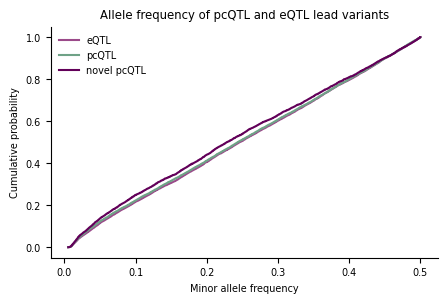

In [15]:
fig, ax = plt.subplots(figsize=(5, 3))

# Create CDF plot for each QTL type
for qtl_type in combined_lead_vars['qtl_type'].unique():
    data = combined_lead_vars[combined_lead_vars['qtl_type'] == qtl_type]['maf'].dropna()
    data_sorted = np.sort(data)
    cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    
    ax.plot(data_sorted, cdf, label=qtl_type, color=qtl_colors[qtl_type], linewidth=1.5)

ax.set_ylabel('Cumulative probability')
ax.set_xlabel('Minor allele frequency')
ax.set_title('Allele frequency of pcQTL and eQTL lead variants')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(['eQTL', 'pcQTL', 'novel pcQTL'], frameon=False)
plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s10.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
stat1, p1 = mannwhitneyu(combined_lead_vars[combined_lead_vars['qtl_type'] == 'pcqtl']['maf'].dropna(), 
                         combined_lead_vars[combined_lead_vars['qtl_type'] == 'eqtl']['maf'].dropna(), 
                         alternative='two-sided')
print(f"eQTL vs pcQTL:")
print(f"  Mann-Whitney U test p-value: {p1:.2e}")
print(f"  Significant difference: {'Yes' if p1 < 0.05 else 'No'}")

stat2, p2 = mannwhitneyu(combined_lead_vars[combined_lead_vars['qtl_type'] == 'pcqtl']['maf'].dropna(), 
                         combined_lead_vars[combined_lead_vars['qtl_type'] == 'pcqtl_only']['maf'].dropna(), 
                         alternative='two-sided')
print(f"pcQTL vs pcQTL only:")
print(f"  Mann-Whitney U test p-value: {p2:.2e}")
print(f"  Significant difference: {'Yes' if p2 < 0.05 else 'No'}")

stat3, p3 = mannwhitneyu(combined_lead_vars[combined_lead_vars['qtl_type'] == 'pcqtl_only']['maf'].dropna(), 
                         combined_lead_vars[combined_lead_vars['qtl_type'] == 'eqtl']['maf'].dropna(), 
                         alternative='two-sided')
print(f"pcQTL only vs eQTL:")
print(f"  Mann-Whitney U test p-value: {p3:.2e}")
print(f"  Significant difference: {'Yes' if p3 < 0.05 else 'No'}")

eQTL vs pcQTL:
  Mann-Whitney U test p-value: 1.64e-01
  Significant difference: No
pcQTL vs pcQTL only:
  Mann-Whitney U test p-value: 1.29e-06
  Significant difference: Yes
pcQTL only vs eQTL:
  Mann-Whitney U test p-value: 1.88e-04
  Significant difference: Yes
